In [1]:
pip install cmsisdsp


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 27.2 MB/s eta 0:00:00


In [2]:
pip install resampy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 23.9 MB/s eta 0:00:00


In [3]:
import cmsisdsp as dsp
import cmsisdsp.fixedpoint as fix
import cmsisdsp.datatype as dt
import numpy as np
import scipy.signal as s
import librosa
import resampy
from IPython import display as ipd
import matplotlib.pyplot as plt
from scipy.io.wavfile import write

Down sampling audio recordings to 800Hz

In [ ]:
y, sr = librosa.load('NHU05032028.wav')

15200


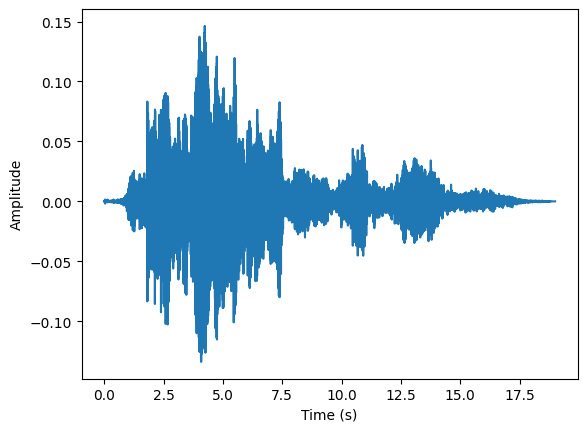

In [ ]:
sec = int(len(y)/sr)
samps = sec*800
print(samps)
downsample_y = s.resample(y, samps)
t = np.linspace(0, len(downsample_y)/800, len(downsample_y))
plt.plot(t, downsample_y)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.show()

ipd.Audio(data=downsample_y, rate=800)

# FFT on speech sample using CMSIS-DSP

In [ ]:
def fft_frames_maker(signal, frame_length, sr, hop_size):
  frames = []
  num_frames = (len(signal) - frame_length) // hop_size + 1
  hamming_window = np.hamming(frame_length)
  hamming_Q15 = fix.toQ15(hamming_window)

  # Create FFT instance
  fft_instance = dsp.arm_rfft_instance_q15()

  # Create frames
  for c in range(num_frames):
    start = c * hop_size
    end = start + frame_length
    frame = signal[start:end]

    ## I would store this from the start

    frame_windowed = dsp.arm_mult_q15(frame, hamming_Q15)

    # Intilise fft using forward process aswell as bit reversal
    status = dsp.arm_rfft_init_q15(fft_instance, frame_length, 0, 1)
    # Create output buffer


    # Applying fft
    frames.append(dsp.arm_rfft_q15(fft_instance, frame_windowed))
  return frames


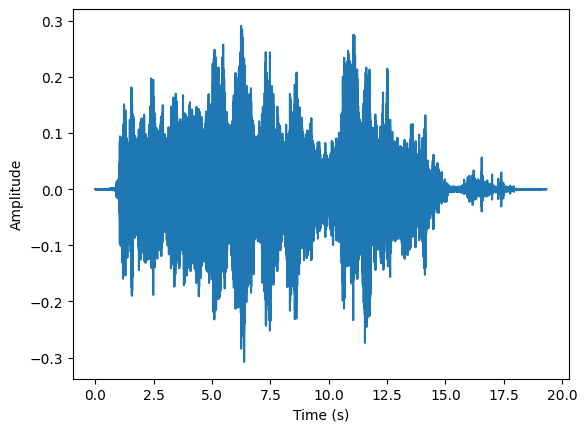

In [ ]:
y_norm = y/np.linalg.norm(downsample_y)
signalQ15 = fix.toQ15(y_norm)
plt.plot(t, y_norm)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
windows = fft_frames_maker(signalQ15, 128, sr, 30) # Should create two frames

ipd.Audio(y_norm, rate=sr)


# FFT inversing and using overlap add


In [ ]:
def reversing_frames(frames, frame_length, sr, hop_size):
  reconstructed_signal = np.zeros(len(frames) * hop_size + frame_length, dtype=np.int16)

  # fft isntance
  fft_instance = dsp.arm_rfft_instance_q15()

  for i, frame in enumerate(frames):
    #Initilise fft
    status = dsp.arm_rfft_init_q15(fft_instance, frame_length, 1, 1)
    inverse_frame = dsp.arm_rfft_q15(fft_instance, frame)

    start = i * hop_size
    end = start + frame_length
    reconstructed_signal[start:end] += inverse_frame
  return reconstructed_signal



In [ ]:
# Reconstructing signal
reconstructed_signal = reversing_frames(windows, 128, sr, 30)

reconstructed_signalf15 = fix.Q15toF32(reconstructed_signal)

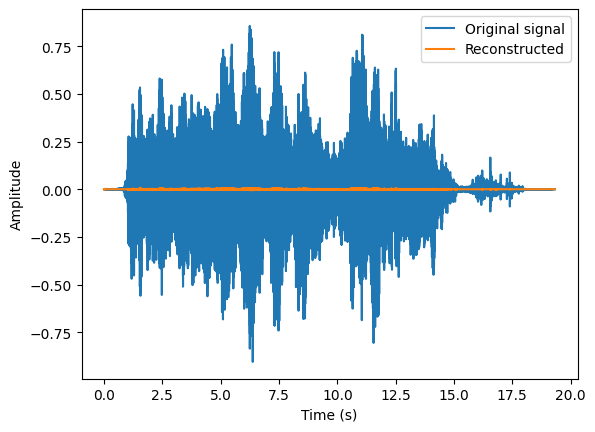

In [ ]:
t = np.linspace(0, len(reconstructed_signalf15)/sr, len(reconstructed_signalf15))
torg = np.linspace(0, len(y_norm)/sr, len(y_norm))
plt.plot(t, reconstructed_signalf15, label='Reconstructed')

plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()

ipd.Audio(reconstructed_signalf15, rate=sr, autoplay=True)

# DWT proccess on same signal


Using this method https://github.com/nerajbobra/wavelet-based-ecg-compression/blob/master/Wavelet-Based%20ECG%20Compression.ipynb

Below are my coeffiencent lengths and bior constants which are used in the low and high filters


In [ ]:
# y is the signal(time domain), sr is the sampling rate
y, sr = librosa.load('NHU05032028.wav', sr=800)

frame_length = 128
COEFF_LENGTH = {'cA5': 11, 'cD5': 11, 'cD4': 15, 'cD3': 23, 'cD2': 38,'cD1': 68}

# Change coeff lengths later

RUN_LENGTH = 4
MAX_PRD = 0.4

#Hard coded bior 4.4 constants
BIOR4_4_CONST_LOW_F = [0.03782845550726404, -0.023849465019556843,
-0.11062440441843718,0.37740285561283066,
0.85269867900889385,0.37740285561283066,
-0.11062440441843718, -0.023849465019556843,
0.03782845550726404]

BIOR4_4_CONST_HIGH_F = [-0.064538882628697058,
-0.040689417609164058, 0.41809227322161724,
0.7884856164055829, 0.41809227322161724,
-0.040689417609164058, -0.064538882628697058]

#Q15 constants
BIOR4_4_CONST_HIGH_Q15 = fix.toQ15(BIOR4_4_CONST_HIGH_F)
BIOR4_4_CONST_LOW_Q15 = fix.toQ15(BIOR4_4_CONST_LOW_F)

THRESH_PERC_APPROX = 0.999
THRESH_PERC_D5 = 0.97
THRESH_PERC_D4_D1 = 0.85

In [ ]:
# Reconstruction constants
BIOR4_4_RECONSTRUCT_LOW = [
-0.064538882628697058,
-0.040689417609164058, 0.41809227322161724,
0.7884856164055829, 0.41809227322161724,
-0.040689417609164058, -0.064538882628697058,
0.0]

BIOR4_4_RECONSTRUCT_LOW_Q15 = fix.toQ15(BIOR4_4_RECONSTRUCT_LOW)

BIOR4_4_RECONSTRUCT_HIGH = [
 0.03782845550726404, -0.023849465019556843,
-0.11062440441843718,0.37740285561283066,
0.85269867900889385,0.37740285561283066,
-0.11062440441843718, -0.023849465019556843,
0.03782845550726404, 0.0
]

BIOR4_4_RECONSTRUCT_HIGH_Q15 = fix.toQ15(BIOR4_4_RECONSTRUCT_HIGH)

Performing DWT

In [ ]:
def dwt(signal):

  coef = {'cA5': None, 'cD5': None, 'cD4': None, 'cD3': None, 'cD2': None, 'cD1': None}

  passed_on = signal
  # For each coeffieciant loop through and apply filters
  for i, current_coef in enumerate(reversed(COEFF_LENGTH)):

    block_size = len(passed_on)
    num_taps_low = len(BIOR4_4_CONST_LOW_Q15)
    num_taps_high = len(BIOR4_4_CONST_HIGH_Q15)

    # Setting pState
    pState_low = np.zeros(num_taps_low + block_size - 1, dtype=np.int16)
    pState_high = np.zeros(num_taps_high + block_size - 1, dtype=np.int16)

    # Intiating FIR decimate filter -NOTE will need to add blockSize for C
    filter_instance_low = dsp.arm_fir_decimate_instance_q15()
    status_low = dsp.arm_fir_decimate_init_q15(filter_instance_low, 9, 2, BIOR4_4_CONST_LOW_Q15, pState_low)

    filter_instance_high = dsp.arm_fir_decimate_instance_q15()
    status_high = dsp.arm_fir_decimate_init_q15(filter_instance_high, 7, 2, BIOR4_4_CONST_HIGH_Q15, pState_high)

    # Applying low pass and high pass depending on coef

    filtered_low = dsp.arm_fir_decimate_q15(filter_instance_low, passed_on)

    filtered_high = dsp.arm_fir_decimate_q15(filter_instance_high, passed_on)

    passed_on = filtered_low

    if current_coef[2] == '5':
      coef['cA5'] = filtered_low
      coef['cD5'] = filtered_high
      break
    else:
      coef[current_coef] = filtered_high
  return coef


Splitting into 128 bit frames

In [ ]:
def frames_maker(signal, frame_length, sr):
  frame_coefs = []
  num_frames = len(signal) // frame_length

  for c in range(num_frames):
    start = c * frame_length
    end = start + frame_length
    frame = signal[start:end]
    dwt_frame = dwt(frame)
    frame_coefs.append(dwt_frame)
  return frame_coefs

# Inverse process of DWT

In [ ]:
def idwt(coef):

  passed_on = coef['cA5']
  for i in range(5, 0, -1):
    block_size = len(passed_on)
    coefcD = coef['cD' + str(i)]

    num_taps_low = len(BIOR4_4_RECONSTRUCT_LOW_Q15)
    num_taps_high = len(BIOR4_4_RECONSTRUCT_HIGH_Q15)

    #Creating buffer size
    pState_high = np.zeros(int(num_taps_high/2)+block_size-1)
    pState_low = np.zeros(int(num_taps_low/2)+block_size-1)

    #Create interpolate instance
    interpolate_high = dsp.arm_fir_interpolate_instance_q15()
    interpolate_low = dsp.arm_fir_interpolate_instance_q15()
    # Initilize the FIR
    status_high = dsp.arm_fir_interpolate_init_q15(interpolate_high, 2, num_taps_high, BIOR4_4_RECONSTRUCT_HIGH_Q15, pState_high)
    status_low = dsp.arm_fir_interpolate_init_q15(interpolate_low, 2, num_taps_low, BIOR4_4_RECONSTRUCT_HIGH_Q15, pState_low)

    #Filter data
    filtered_high = dsp.arm_fir_interpolate_q15(interpolate_high, coefcD)
    filtered_low = dsp.arm_fir_interpolate_q15(interpolate_low, passed_on)

    #Combine low and high pass filters
    passed_on = filtered_high + filtered_low
  return passed_on




Reconstruct frames

In [ ]:
def inverseFrames(frames, frame_length, sr):
  reconstructed_signal = np.zeros(len(frames) * frame_length, dtype=np.int16)
  for i, frame in enumerate(frames):
    start = i * frame_length
    end = start + frame_length
    reconstructed_signal[start:end] += idwt(frame)
  return reconstructed_signal

Test signal through DWT

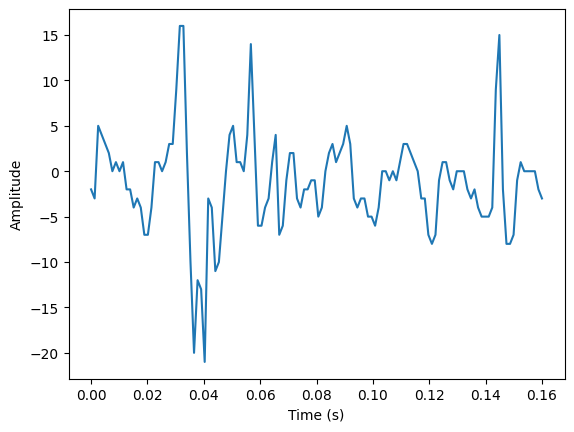

In [ ]:
y_norm = y / np.linalg.norm(y)
test_signal = fix.toQ15(y_norm[:128])
t = np.linspace(0, len(test_signal)/sr, len(test_signal))
plt.plot(t, test_signal)
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
coef = dwt(test_signal)


Text(0, 0.5, 'Amplitude')

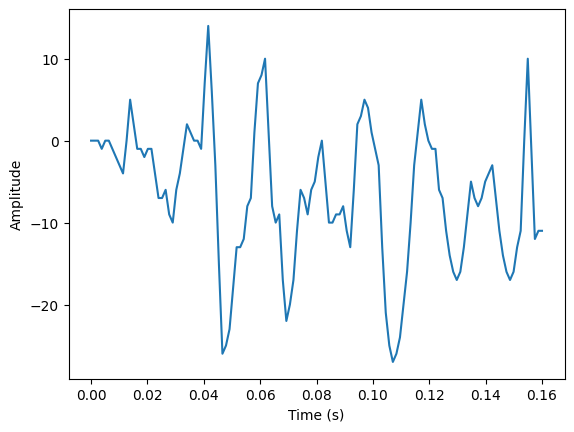

In [ ]:
reconstructed_signal = idwt(coef)
reconstructed_signalf15 = fix.Q15toF32(reconstructed_signal)
ts = np.linspace(0, len(reconstructed_signalf15)/sr, len(reconstructed_signalf15))
plt.plot(ts, reconstructed_signal, label='Reconstructed Signal')
#plt.plot(t, test_signal, label='test_signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')


Full signal through DWT

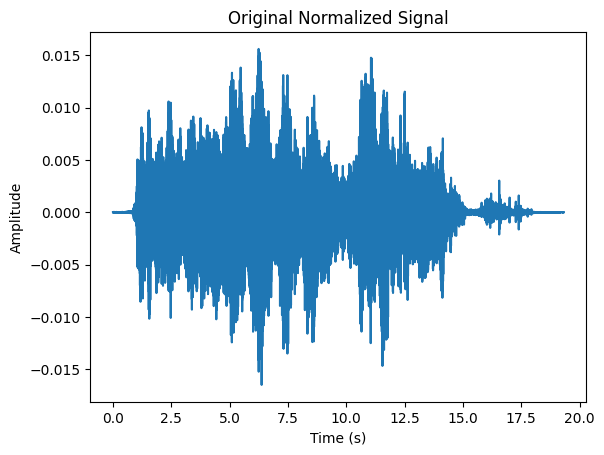

In [ ]:
y_norm = y / np.linalg.norm(y)


q15_y = fix.toQ15(y_norm)

t = np.linspace(0, len(y_norm)/sr, len(y_norm))
plt.plot(t, y_norm)
plt.title("Original Normalized Signal")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.show()

frames = frames_maker(q15_y, 128, sr)


ipd.Audio(y, rate=sr)

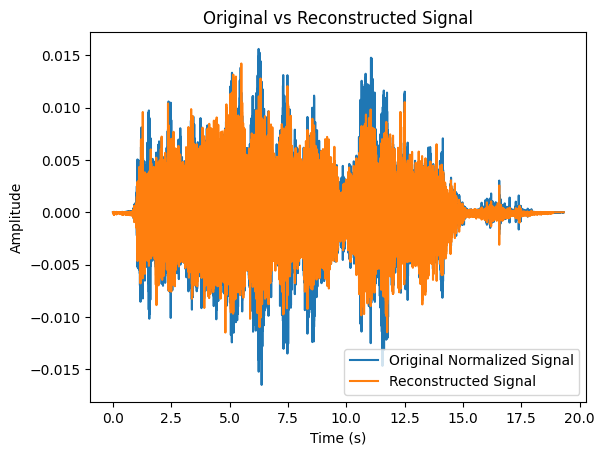

In [ ]:
reconstructed_signal_q15 = inverseFrames(frames, 128, sr)

reconstructed_signal = fix.Q15toF32(reconstructed_signal_q15)

t = np.linspace(0, len(y_norm)/sr, len(y_norm))
tsignal = np.linspace(0, len(reconstructed_signal)/sr, len(reconstructed_signal))
plt.plot(t, y_norm, label='Original Normalized Signal')
plt.plot(tsignal, reconstructed_signal, label='Reconstructed Signal')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.title('Original vs Reconstructed Signal')
plt.show() # Ensure plot is displayed

ipd.Audio(data=reconstructed_signal, rate=sr)

# Pre-proccessing steps for both


*   Detrending
*   Possibly more...?




In [54]:
def detrend(signal):
  #newdata[sl] = newdata[sl] - A @ coef
  block_size = 32 # Can change to fit processor better

  blocks = signal.shape[0] // block_size

  detrend_signal = np.zeros(signal.shape)

  # Settings for filter
  numTaps = 1
  mu = 0.01 # IMPORTANT tune this
  mu_q15 = fix.toQ15(mu)
  post_shift = 4
  post_shift = fix.toQ15(post_shift)
  pstate_size = numTaps+block_size-1
  pstate = np.zeros(pstate_size, dtype=np.int16)
  pcoefs = np.zeros(numTaps, dtype=np.int16)

  # CMSIS-DSP normalised least mean squared filter intiation
  nlms_instance = dsp.arm_lms_norm_instance_q15()
  # Add back in blocksize in C
  status = dsp.arm_lms_norm_init_q15(nlms_instance, numTaps, pcoefs, pstate, mu_q15, post_shift)

  # Calculating the reference signal
  ref_signal = fix.toQ15(np.ones(block_size))
  # Create 4 blocks 32bit
  for i in range(blocks):
    empty_err = np.zeros(block_size, dtype=np.int16)

    start = i * block_size
    end = start + block_size
    current_block = signal[start:end]

    # Applying filter
    pOut = dsp.arm_lms_norm_q15(nlms_instance, current_block, ref_signal, empty_err)
    perr = current_block - pOut
    t = np.linspace(0, len(perr)/sr, len(perr))


    detrend_signal[start:end] = perr
  return detrend_signal

# Compression and thresholding for both ##TODO


In [ ]:
def thresholding()

# Compression ratio comparision ##TODO


1.   Threshold FFT and DWT coeffiecents(get rid of unuesed freq
2.   Quantize the coefs
3. Binary map?...



Below is testing of preprocessing

In [10]:
data = np.genfromtxt('teth_C1_B1_3.data', delimiter=',', skip_header=1)

laser_data = data[:, 1]
#acceler_data = data[:, 2]

sensitivy = 125.0
sr = 10240
velocity_data = laser_data * sensitivy

# t_data = np.linspace(0, len(velocity_data)/sr, len(velocity_data))
# plt.plot(t_data, velocity_data)
# plt.xlabel('Time (s)')
# plt.ylabel('Amplitude')

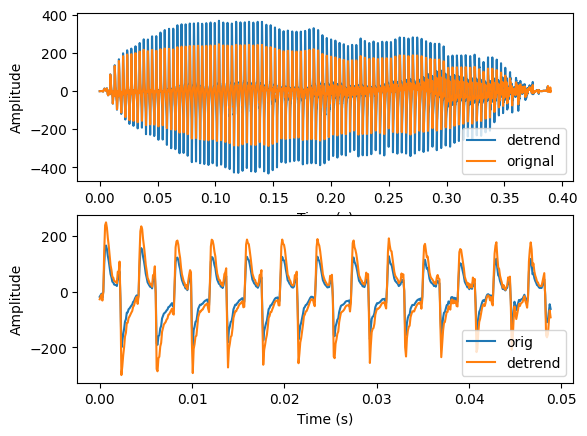

In [55]:
# data, sr = librosa.load('NHU05032028.wav')
# data = fix.toQ15(data)

data_detrend = detrend(velocity_data)
t = np.linspace(0, len(data_detrend)/sr, len(data_detrend))

t_400 = np.linspace(0, 500/sr, 500)

plt.subplot(2, 1, 1)
plt.plot(t, data_detrend, label='detrend')
plt.plot(t, velocity_data, label='orignal')
plt.legend()
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

plt.subplot(2, 1, 2)
plt.plot(t_400, velocity_data[3000:3500], label='orig')
plt.plot(t_400, data_detrend[3000:3500], label='detrend')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()



In [ ]:
def get_compression()
    #each value in the compressed coefficients is 8 bits
    num_bits_compressed = len(coeffs_compressed)*8

    #the number of bits in the last byte of the compressed coeffs is 8
    #and another 8 bits for the last byte of the compressed binary map
    num_bits_compressed = num_bits_compressed + 16

    #each set of scaling factors has 2 float values, and each float value is 32 bits
    num_bits_compressed = num_bits_compressed + len(scaling_factors)*2*32

    #the number of bits corresponds to one byte
    num_bits_compressed = num_bits_compressed + 8

    #each value in the compressed binary map is 8 bits
    num_bits_compressed = num_bits_compressed + len(binary_map_compressed)*8

    #the initial state of the binary map is just one bit but assume it's stored as a byte
    num_bits_compressed = num_bits_compressed + 8

    #each of the original data are 16 bits
    num_bits_uncompressed = NUM_SAMPLES_BLOCK*16

    #get the compression ratio
    compression_ratio = num_bits_uncompressed/num_bits_compressed

    return compression_ratio